In [1]:
# --- Import necessary libraries ---
import pandas as pd  # For data manipulation and creating DataFrames
import numpy as np   # For numerical operations and array mathematics
import matplotlib.pyplot as plt # For creating plots and visualizations

# --- 1. USER INPUT: Final data for the analysis ---
# These values are pre-calculated from the raw historical stock data.
# This script focuses on the portfolio optimization based on these inputs.

# Define the 5 domestic stocks for the analysis
TICKERS = [
    'Godrej Consumer Products', 'AstraZeneca Pharma India', 'Coforge',
    'Brigade Enterprises', 'Gujarat Gas'
]

# Pre-calculated average daily returns for the 5 stocks (from April 2024 - March 2025)
mean_daily_returns_raw = np.array([
    -0.000149778872545963, 0.00230701509239115, 0.00181189721193134,
    0.000523293968085389, -0.000918337031875341
])

# Pre-calculated 5x5 daily covariance matrix for the 5 stocks
daily_cov_matrix_raw = np.array([
    [0.000318707461070137, 0.0000710329695847228, 0.00000945155080698493, 0.0000152628397190216, 0.0000203767863174846],
    [0.0000710329695847228, 0.000792674282494121, 0.000120504943727395, 0.0000390696996304103, 0.0000702883934203501],
    [0.00000945155080698493, 0.000120504943727395, 0.000512846066659901, 0.000130513712006342, 0.000108283281755849],
    [0.0000152628397190216, 0.0000390696996304103, 0.000130513712006342, 0.000704186993922603, 0.000185191288326579],
    [0.0000203767863174846, 0.0000702883934203501, 0.000108283281755849, 0.000185191288326579, 0.000394968626125669]
])

# The established annual risk-free rate, calculated from 91-day T-bill averages
RISK_FREE_RATE_ANNUAL = 0.0666228
# Set the number of random portfolios to generate for the simulation
NUM_PORTFOLIOS = 1000000

# --- 2. Monte Carlo Simulation ---
# This section simulates a large number of random portfolios to map out the
# entire set of possible risk-return combinations.
print(f"Running Monte Carlo simulation for {NUM_PORTFOLIOS} portfolios...")

portfolio_results = []  # Initialize an empty list to store the results of each loop
num_assets = len(TICKERS) # Get the number of assets (5)

for i in range(NUM_PORTFOLIOS):
    # Generate a set of random numbers, one for each asset
    weights = np.random.random(num_assets)
    # Normalize the weights so they sum to 1 (representing 100% allocation)
    weights /= np.sum(weights)

    # --- Calculate portfolio metrics using Markowitz formulas ---

    # Calculate the expected annual portfolio return (Arithmetic mean)
    # Formula: (w1*r1 + w2*r2 + ...) * 252
    portfolio_return = np.sum(mean_daily_returns_raw * weights) * 252

    # Calculate the expected annual portfolio volatility (risk)
    # Formula: sqrt(wT * Cov * w) * sqrt(252)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(daily_cov_matrix_raw, weights))) * np.sqrt(252)

    # Calculate the Sharpe Ratio (risk-adjusted return)
    # Formula: (Portfolio Return - Risk-Free Rate) / Portfolio Volatility
    sharpe_ratio = (portfolio_return - RISK_FREE_RATE_ANNUAL) / portfolio_volatility

    # Store the results of this portfolio
    portfolio_results.append([portfolio_return, portfolio_volatility, sharpe_ratio] + list(weights))

# Convert the list of results into a pandas DataFrame for easier analysis
results_frame = pd.DataFrame(
    portfolio_results,
    columns=['Return', 'Volatility', 'Sharpe'] + TICKERS
)

# --- 3. Identify Key Portfolios from Simulation Results ---
print("\nIdentifying key portfolios from the simulation...")

# Find the Minimum Variance Portfolio (MVP):
# This is the portfolio with the single lowest volatility (risk) in the entire simulation.
min_variance_portfolio = results_frame.iloc[results_frame['Volatility'].idxmin()]

# Find the Tangency Portfolio (Maximum Sharpe Ratio Portfolio):
# This is the single most efficient portfolio, offering the best risk-adjusted return.
tangency_portfolio = results_frame.iloc[results_frame['Sharpe'].idxmax()]

# --- Print the details for the Minimum Variance Portfolio ---
print("\n--- Minimum Variance Portfolio ---")
print(f"Coordinates: [Volatility: {min_variance_portfolio['Volatility']:.4f}, Return: {min_variance_portfolio['Return']:.4f}]")
print("Weights:")
# Format the weights as percentages and use .to_string() to remove the extra "Name" line
print(min_variance_portfolio[TICKERS].apply(lambda x: f"{x:.2%}").to_string())

# --- Print the details for the Tangency Portfolio ---
print("\n--- Tangency Portfolio (Max Sharpe Ratio) ---")
print(f"Coordinates: [Volatility: {tangency_portfolio['Volatility']:.4f}, Return: {tangency_portfolio['Return']:.4f}]")
print(f"Sharpe Ratio: {tangency_portfolio['Sharpe']:.2f}")
print("Weights:")
# Format the weights as percentages and use .to_string() to remove the extra "Name" line
print(tangency_portfolio[TICKERS].apply(lambda x: f"{x:.2%}").to_string())

# --- 4. Identify the True Efficient Frontier Points for Plotting ---
# This section isolates the *actual* efficient frontier from the cloud of random points.
print("\nIdentifying the efficient frontier points for demarcation...")

# The efficient frontier only consists of portfolios that have a return
# greater than or equal to the Minimum Variance Portfolio.
frontier_candidates = results_frame[results_frame['Return'] >= min_variance_portfolio['Return']]
efficient_frontier_points = []
# Sort these candidates by risk (volatility) from low to high
sorted_candidates = frontier_candidates.sort_values(by='Volatility')

# Iterate through the sorted list and only select points that represent a new
# maximum return for their level of risk. This traces the upper-left boundary.
max_return_so_far = -np.inf
for index, row in sorted_candidates.iterrows():
    if row['Return'] > max_return_so_far:
        max_return_so_far = row['Return']
        efficient_frontier_points.append(row)

# Convert the final list of frontier points into a DataFrame for plotting
frontier_frame = pd.DataFrame(efficient_frontier_points)


# --- 5. Plot the Final, Corrected Graph ---
print("\nGenerating the final plot...")
# Create a large figure to hold the plot
plt.figure(figsize=(14, 8))

# Plot all 1,000,000 simulated portfolios as a scatter plot
# Color-code each point by its Sharpe Ratio (using the 'viridis' colormap)
plt.scatter(
    results_frame['Volatility'], results_frame['Return'], c=results_frame['Sharpe'],
    cmap='viridis', marker='o', s=10, alpha=0.3, label='Simulated Portfolios'
)
# Add a color bar to explain the Sharpe Ratio colors
cbar = plt.colorbar()
cbar.set_label('Sharpe Ratio')

# Plot the TRUE efficient frontier by connecting the actual optimal points
# This creates the solid blue line tracing the boundary of the simulated points
plt.plot(frontier_frame['Volatility'], frontier_frame['Return'], 'b-', linewidth=2.5, label='Efficient Frontier')

# Plot the Capital Allocation Line (CAL)
# This is the red line from the risk-free rate to the tangency portfolio
cal_x = [0, tangency_portfolio['Volatility']]
cal_y = [RISK_FREE_RATE_ANNUAL, tangency_portfolio['Return']]
plt.plot(cal_x, cal_y, 'r-', linewidth=2.0, label='Capital Allocation Line')

# --- Mark the key portfolios on the graph ---
# Mark the Tangency Portfolio with a large red star
plt.scatter(tangency_portfolio['Volatility'], tangency_portfolio['Return'],
            marker='*', color='red', s=500, label='Tangency Portfolio')
# Mark the Minimum Variance Portfolio with a large orange star
plt.scatter(min_variance_portfolio['Volatility'], min_variance_portfolio['Return'],
            marker='*', color='orange', s=500, label='Minimum Variance Portfolio')
# Mark the Risk-Free Rate on the y-axis with a large blue plus sign
plt.scatter(0, RISK_FREE_RATE_ANNUAL, marker='P', color='blue', s=300, label='Risk-Free Rate')

# --- Final plot formatting ---
plt.title('Efficient Frontier with Monte Carlo Simulation', fontsize=18)
plt.xlabel('Annualized Volatility (Risk)', fontsize=14)
plt.ylabel('Annualized Return', fontsize=14)

# Set axis limits to ensure the y-intercept (Risk-Free Rate) is clearly visible
plt.xlim(0, results_frame['Volatility'].max() * 1.1)
y_min = min(0, results_frame['Return'].min()) # Start y-axis at 0 or lower
plt.ylim(y_min * 1.2, results_frame['Return'].max() * 1.1)

# Display the plot legend
plt.legend(labelspacing=0.8, loc='upper left')
# Add a grid for readability
plt.grid(True)
# Display the final, combined graph
plt.show()

print("\nPlot displayed successfully.")

ModuleNotFoundError: No module named 'pandas'

Running Monte Carlo simulation for 1000000 portfolios...

Identifying key portfolios from the 6-stock simulation...

--- Minimum Variance Portfolio ---
Coordinates: [Volatility: 0.1832, Return: 0.1059]
Weights:
Godrej Consumer Products    35.05%
AstraZeneca Pharma India     7.80%
Coforge                     17.39%
Brigade Enterprises         10.59%
Gujarat Gas                 20.83%
NVIDIA Corporation           8.34%

--- Tangency Portfolio (Max Sharpe Ratio) ---
Coordinates: [Volatility: 0.2726, Return: 0.4750]
Sharpe Ratio: 1.50
Weights:
Godrej Consumer Products     1.16%
AstraZeneca Pharma India    39.35%
Coforge                     43.55%
Brigade Enterprises          1.60%
Gujarat Gas                  0.59%
NVIDIA Corporation          13.74%

Identifying the efficient frontier points for demarcation...

Generating the final plot...


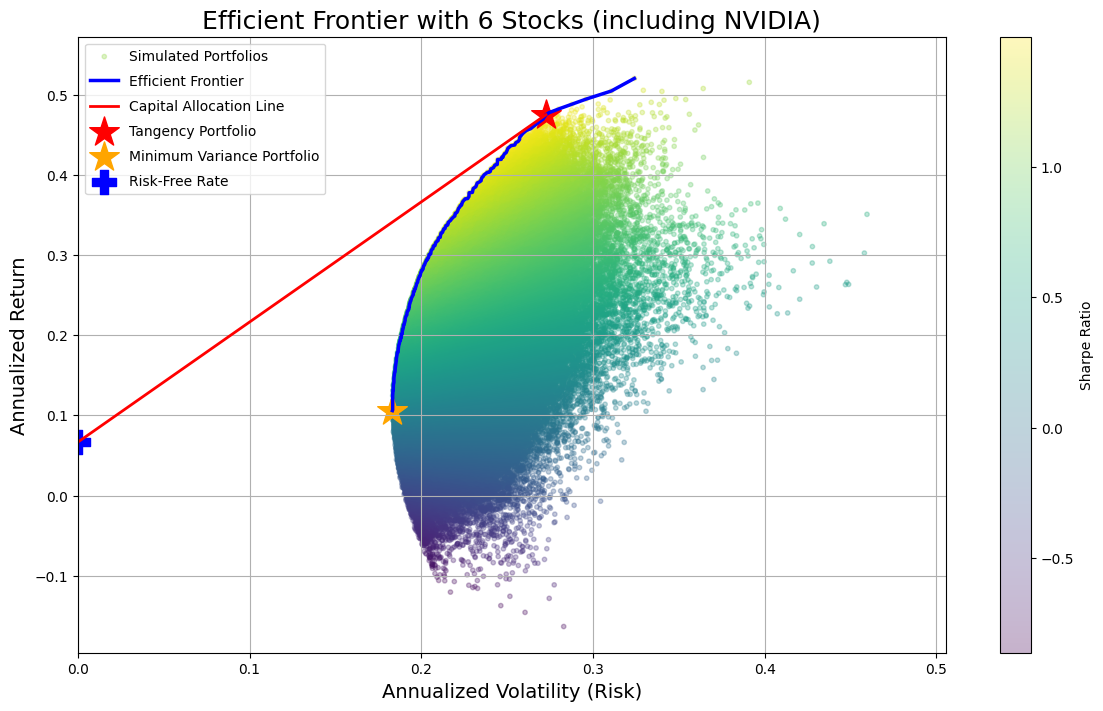


Plot displayed successfully.


In [ ]:
# --- Import necessary libraries ---
import pandas as pd  # For data manipulation and creating DataFrames
import numpy as np   # For numerical operations and array mathematics
import matplotlib.pyplot as plt # For creating plots and visualizations

# --- 1. USER INPUT: Expanded for 6 stocks ---
# This script analyzes the 5 domestic stocks plus one international stock (NVIDIA).

# Define the 6 stocks for the analysis
TICKERS = [
    'Godrej Consumer Products', 'AstraZeneca Pharma India', 'Coforge',
    'Brigade Enterprises', 'Gujarat Gas', 'NVIDIA Corporation'
]

# --- Pre-calculated 6-Asset Data ---
# These values were calculated by analyzing the historical data for all 6 stocks
# for the same period (April 2024 - March 2025).

# Pre-calculated average daily returns for the 6 stocks
mean_daily_returns_raw = np.array([
    -0.000149778872545963, 0.00230701509239115, 0.00181189721193134,
    0.000523293968085389, -0.000918337031875341, 0.00136048947102199
])

# Pre-calculated 6x6 daily covariance matrix for the 6 stocks
daily_cov_matrix_raw = np.array([
    [0.000318707461070137, 0.0000710329695847228, 0.00000945155080698493, 0.0000152628397190216, 0.0000203767863174846, 0.0000412450745537908],
    [0.0000710329695847228, 0.000792674282494121, 0.000120504943727395, 0.0000390696996304103, 0.0000702883934203501, 0.0000465924696010827],
    [0.00000945155080698493, 0.000120504943727395, 0.000512846066659901, 0.000130513712006342, 0.000108283281755849, 0.00000349688090235056],
    [0.0000152628397190216, 0.0000390696996304103, 0.000130513712006342, 0.000704186993922603, 0.000185191288326579, -0.0000922405377238247],
    [0.0000203767863174846, 0.0000702883934203501, 0.000108283281755849, 0.000185191288326579, 0.000394968626125669, 0.0000612094682139907],
    [0.0000412450745537908, 0.0000465924696010827, 0.00000349688090235056, -0.0000922405377238247, 0.0000612094682139907, 0.00127093546190846]
])

# Use the same Annual Risk-Free Rate as before
RISK_FREE_RATE_ANNUAL = 0.0666228
# Set the number of random portfolios to generate for the simulation
NUM_PORTFOLIOS = 1000000

# --- 2. Monte Carlo Simulation (for 6 assets) ---
# This section simulates a large number of random portfolios to map out the
# entire set of possible risk-return combinations for the 6-stock portfolio.
print(f"Running Monte Carlo simulation for {NUM_PORTFOLIOS} portfolios...")

portfolio_results = []  # Initialize an empty list to store the results of each loop
num_assets = len(TICKERS) # Get the number of assets (now 6)

for i in range(NUM_PORTFOLIOS):
    # Generate a set of random numbers, one for each asset
    weights = np.random.random(num_assets)
    # Normalize the weights so they sum to 1 (representing 100% allocation)
    weights /= np.sum(weights)

    # --- Calculate portfolio metrics using Markowitz formulas ---

    # Calculate the expected annual portfolio return
    # Formula: (w1*r1 + w2*r2 + ...) * 252
    portfolio_return = np.sum(mean_daily_returns_raw * weights) * 252

    # Calculate the expected annual portfolio volatility (risk)
    # Formula: sqrt(wT * Cov * w) * sqrt(252)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(daily_cov_matrix_raw, weights))) * np.sqrt(252)

    # Calculate the Sharpe Ratio (risk-adjusted return)
    # Formula: (Portfolio Return - Risk-Free Rate) / Portfolio Volatility
    sharpe_ratio = (portfolio_return - RISK_FREE_RATE_ANNUAL) / portfolio_volatility

    # Store the results of this portfolio
    portfolio_results.append([portfolio_return, portfolio_volatility, sharpe_ratio] + list(weights))

# Convert the list of results into a pandas DataFrame for easier analysis
results_frame = pd.DataFrame(
    portfolio_results,
    columns=['Return', 'Volatility', 'Sharpe'] + TICKERS
)

# --- 3. Identify Key Portfolios from Simulation Results ---
print("\nIdentifying key portfolios from the 6-stock simulation...")

# Find the Minimum Variance Portfolio (MVP):
# This is the portfolio with the single lowest volatility (risk) in the entire simulation.
min_variance_portfolio = results_frame.iloc[results_frame['Volatility'].idxmin()]

# Find the Tangency Portfolio (Maximum Sharpe Ratio Portfolio):
# This is the single most efficient portfolio, offering the best risk-adjusted return.
tangency_portfolio = results_frame.iloc[results_frame['Sharpe'].idxmax()]

# --- Print the details for the Minimum Variance Portfolio ---
print("\n--- Minimum Variance Portfolio ---")
print(f"Coordinates: [Volatility: {min_variance_portfolio['Volatility']:.4f}, Return: {min_variance_portfolio['Return']:.4f}]")
print("Weights:")
# Format the weights as percentages and use .to_string() to remove the extra "Name" line
print(min_variance_portfolio[TICKERS].apply(lambda x: f"{x:.2%}").to_string())

# --- Print the details for the Tangency Portfolio ---
print("\n--- Tangency Portfolio (Max Sharpe Ratio) ---")
print(f"Coordinates: [Volatility: {tangency_portfolio['Volatility']:.4f}, Return: {tangency_portfolio['Return']:.4f}]")
print(f"Sharpe Ratio: {tangency_portfolio['Sharpe']:.2f}")
print("Weights:")
# Format the weights as percentages and use .to_string() to remove the extra "Name" line
print(tangency_portfolio[TICKERS].apply(lambda x: f"{x:.2%}").to_string())

# --- 4. Identify the True Efficient Frontier Points for Plotting ---
# This section isolates the *actual* efficient frontier from the cloud of random points.
print("\nIdentifying the efficient frontier points for demarcation...")

# The efficient frontier only consists of portfolios that have a return
# greater than or equal to the Minimum Variance Portfolio.
frontier_candidates = results_frame[results_frame['Return'] >= min_variance_portfolio['Return']]
efficient_frontier_points = []
# Sort these candidates by risk (volatility) from low to high
sorted_candidates = frontier_candidates.sort_values(by='Volatility')

# Iterate through the sorted list and only select points that represent a new
# maximum return for their level of risk. This traces the upper-left boundary.
max_return_so_far = -np.inf
for index, row in sorted_candidates.iterrows():
    if row['Return'] > max_return_so_far:
        max_return_so_far = row['Return']
        efficient_frontier_points.append(row)

# Convert the final list of frontier points into a DataFrame for plotting
frontier_frame = pd.DataFrame(efficient_frontier_points)


# --- 5. Plot the Final, Corrected Graph ---
print("\nGenerating the final plot...")
# Create a large figure to hold the plot
plt.figure(figsize=(14, 8))

# Plot all simulated portfolios as a scatter plot
# Color-code each point by its Sharpe Ratio (using the 'viridis' colormap)
plt.scatter(
    results_frame['Volatility'], results_frame['Return'], c=results_frame['Sharpe'],
    cmap='viridis', marker='o', s=10, alpha=0.3, label='Simulated Portfolios'
)
# Add a color bar to explain the Sharpe Ratio colors
cbar = plt.colorbar()
cbar.set_label('Sharpe Ratio')

# Plot the TRUE efficient frontier by connecting the actual optimal points
# This creates the solid blue line tracing the boundary of the simulated points
plt.plot(frontier_frame['Volatility'], frontier_frame['Return'], 'b-', linewidth=2.5, label='Efficient Frontier')

# Plot the Capital Allocation Line (CAL)
# This is the red line from the risk-free rate to the tangency portfolio
cal_x = [0, tangency_portfolio['Volatility']]
cal_y = [RISK_FREE_RATE_ANNUAL, tangency_portfolio['Return']]
plt.plot(cal_x, cal_y, 'r-', linewidth=2.0, label='Capital Allocation Line')

# --- Mark the key portfolios on the graph ---
# Mark the Tangency Portfolio with a large red star
plt.scatter(tangency_portfolio['Volatility'], tangency_portfolio['Return'],
            marker='*', color='red', s=500, label='Tangency Portfolio')
# Mark the Minimum Variance Portfolio with a large orange star
plt.scatter(min_variance_portfolio['Volatility'], min_variance_portfolio['Return'],
            marker='*', color='orange', s=500, label='Minimum Variance Portfolio')
# Mark the Risk-Free Rate on the y-axis with a large blue plus sign
plt.scatter(0, RISK_FREE_RATE_ANNUAL, marker='P', color='blue', s=300, label='Risk-Free Rate')

# --- Final plot formatting ---
plt.title('Efficient Frontier with 6 Stocks (including NVIDIA)', fontsize=18)
plt.xlabel('Annualized Volatility (Risk)', fontsize=14)
plt.ylabel('Annualized Return', fontsize=14)

# Set axis limits to ensure the y-intercept (Risk-Free Rate) is clearly visible
plt.xlim(0, results_frame['Volatility'].max() * 1.1)
y_min = min(0, results_frame['Return'].min()) # Start y-axis at 0 or lower
plt.ylim(y_min * 1.2, results_frame['Return'].max() * 1.1)

# Display the plot legend
plt.legend(labelspacing=0.8, loc='upper left')
# Add a grid for readability
plt.grid(True)
# Display the final, combined graph
plt.show()

print("\nPlot displayed successfully.")

In [2]:
# --- Import necessary libraries ---
import pandas as pd  # For data manipulation and creating DataFrames
import numpy as np   # For numerical operations and array mathematics
import matplotlib.pyplot as plt # For creating plots and visualizations
import yfinance as yf # For downloading historical stock market data
from scipy import stats # For performing the linear regression to find Beta
import warnings      # To suppress non-critical warning messages

# --- Suppress the benign FutureWarning from yfinance ---
# This hides a common warning from the yfinance library that doesn't affect the result
warnings.simplefilter(action='ignore', category=FutureWarning)


# --- 1. MASTER INPUTS ---
# Define the 5 original domestic stock tickers for your portfolio
TICKERS_YFINANCE = [
    'GODREJCP.NS', 'ASTRAZEN.NS', 'COFORGE.NS', 'BRIGADE.NS', 'GUJGASLTD.NS'
]
# Define the display names for plotting and tables
TICKERS_DISPLAY = [
    'Godrej Consumer Products', 'AstraZeneca Pharma India', 'Coforge',
    'Brigade Enterprises', 'Gujarat Gas'
]
# Define the ticker for your market index (Nifty 50)
MARKET_INDEX = '^NSEI'
# Define the date range for your analysis
START_DATE = '2024-04-01'
END_DATE = '2025-03-31'
# Use the final determined Annual Risk-Free Rate
RISK_FREE_RATE_ANNUAL = 0.0666228

# --- 2. Download Stock and Market Data ---
print("Downloading historical stock and market index data...")
# Combine all tickers (5 stocks + 1 index) into a single list for one download request
all_tickers = TICKERS_YFINANCE + [MARKET_INDEX]
# Download the 'Close' price data for all assets in the specified date range
data = yf.download(all_tickers, start=START_DATE, end=END_DATE, progress=False)['Close']

# --- 3. Calculate Daily Returns and Excess Returns ---
print("\nCalculating daily returns...")
# Calculate the daily percentage change for all assets
daily_returns = data.pct_change().dropna() # .dropna() removes the first row (NaN)

# Convert the annual risk-free rate to its daily equivalent
# This is crucial for the daily regression analysis
# Formula: (1 + Annual Rate)^(1/Trading Days) - 1
daily_risk_free_rate = (1 + RISK_FREE_RATE_ANNUAL)**(1/252) - 1
print(f"Calculated Daily Risk-Free Rate: {daily_risk_free_rate:.6f}")

# Calculate the daily Market Risk Premium (Market's excess return)
# Formula: Market Daily Return - Daily Risk-Free Rate
market_excess_returns = daily_returns[MARKET_INDEX] - daily_risk_free_rate

# --- 4. Calculate Beta and CAPM for Each Stock using Excess Returns ---
print("\n--- Calculating Beta and Required Return (CAPM) for each stock ---")

# Calculate the average annual market return (using raw returns) for the final CAPM formula
market_daily_return = daily_returns[MARKET_INDEX].mean()
market_annual_return = market_daily_return * 252

# Create a place to store the results for the final summary table
capm_results = []
betas = {} # Dictionary to store betas for the summary plots

# Loop through each of the 5 domestic stocks
for i, ticker in enumerate(TICKERS_YFINANCE):
    stock_name = TICKERS_DISPLAY[i]

    # Add a separator for better organization
    print("\n" + "-"*70)
    print(f"Analyzing: {stock_name}")
    print("-"*70)

    # Calculate the stock's daily excess return
    # Formula: Stock Daily Return - Daily Risk-Free Rate
    stock_excess_returns = daily_returns[ticker] - daily_risk_free_rate

    # --- a) Calculate Beta using the theoretically correct regression ---
    # Beta is the slope of the regression between the stock's excess return (Y)
    # and the market's excess return (X).
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        market_excess_returns,
        stock_excess_returns
    )
    beta = slope # The slope of this regression is Beta
    betas[stock_name] = beta # Store beta for later plots
    print(f"  - Calculated Beta (β): {beta:.4f}")

    # --- b) Calculate Required Return using CAPM formula ---
    # Formula: R_stock = R_f + Beta * (R_market - R_f)
    required_return_annual = RISK_FREE_RATE_ANNUAL + beta * (market_annual_return - RISK_FREE_RATE_ANNUAL)
    required_return_daily = required_return_annual / 252 # De-annualize for the table
    print(f"  - Required Annual Return (CAPM): {required_return_annual:.2%}")
    # Store all results for this stock
    capm_results.append([stock_name, beta, required_return_daily, required_return_annual])

    # --- c) Generate the Individual Security Market Line (SML) Plot ---
    # This plot shows the stock's actual returns against the market risk premium
    plt.figure(figsize=(10, 6))
    # Scatter plot of the RAW daily stock return (Y-axis) vs. the daily market risk premium (X-axis)
    plt.scatter(market_excess_returns, daily_returns[ticker], alpha=0.5, label='Actual Daily Returns')

    # Plot the Security Market Line (SML)
    # This line shows the *theoretically required* return for each level of market risk
    # Equation: y = daily_rf_rate + beta * x
    sml_line = daily_risk_free_rate + beta * market_excess_returns
    plt.plot(market_excess_returns, sml_line, 'r', label=f'Security Market Line (β = {beta:.2f})')

    # Add text annotation to clearly state the y-intercept
    plt.text(0.05, 0.95, f'Y-Intercept (Daily Rf): {daily_risk_free_rate:.6f}',
             horizontalalignment='left', verticalalignment='top',
             transform=plt.gca().transAxes, bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    plt.title(f'Security Market Line (SML) for {stock_name}', fontsize=16)
    plt.xlabel('Market Daily Excess Return (Market Risk Premium)', fontsize=12)
    plt.ylabel(f'{stock_name} Daily Return', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show() # Display the plot for this stock before moving to the next

# --- 5. Display Final Summary Table ---
# Consolidate all results into a single DataFrame
results_df = pd.DataFrame(capm_results, columns=['Stock', 'Beta (β)', 'Required Daily Return', 'Required Annual Return'])

# Add separators and a centered title for the final table
print("\n\n" + "="*90)
print("--- Final Summary of CAPM Analysis ---".center(90))
print("="*90)

# Format the columns before printing to ensure proper alignment
results_df_to_print = results_df.copy()
results_df_to_print['Beta (β)'] = results_df_to_print['Beta (β)'].map('{:.6f}'.format)
results_df_to_print['Required Daily Return'] = results_df_to_print['Required Daily Return'].map('{:.6f}'.format)
results_df_to_print['Required Annual Return'] = results_df_to_print['Required Annual Return'].map('{:.2%}'.format)

# Using to_string() on the formatted DataFrame provides a clean, aligned text table
print(results_df_to_print.to_string(index=False))
print("="*90)


# --- 6. Generate Summary Plots ---
print("\nGenerating summary plots...")

# --- a) Combined SML Plot ---
# This plot shows all 5 SMLs on one graph for easy comparison of their slopes (Betas)
print("\nGenerating Combined SML Plot...")
plt.figure(figsize=(12, 8))
# Define a range of x-values (market risk premiums) for plotting the lines
x_range = np.linspace(market_excess_returns.min(), market_excess_returns.max(), 100)
# Create a color map to give each stock a different color
colors = plt.cm.viridis(np.linspace(0, 1, len(TICKERS_DISPLAY)))

for i, (stock_name, beta_val) in enumerate(betas.items()):
    # Calculate the SML for this stock
    sml_y = daily_risk_free_rate + beta_val * x_range
    plt.plot(x_range, sml_y, color=colors[i], label=f'{stock_name} (β = {beta_val:.2f})')

# Mark the risk-free rate (the y-intercept for all lines) and include its value in the legend
plt.scatter(0, daily_risk_free_rate, marker='P', color='blue', s=200,
            label=f'Daily Risk-Free Rate ({daily_risk_free_rate:.6f})', zorder=5) # zorder=5 ensures it's plotted on top

plt.title('Combined Security Market Lines (SMLs)', fontsize=16)
plt.xlabel('Market Daily Excess Return (Market Risk Premium)', fontsize=12)
plt.ylabel('Expected Daily Return', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)
# ** Explicitly show the first plot before creating the second one **
plt.show()


# --- b) Beta Comparison Bar Chart ---
# This plot provides a simple visual comparison of the risk of each stock.
print("\nGenerating Beta Comparison Bar Chart...")
plt.figure(figsize=(10, 6))
stock_names = list(betas.keys())
beta_values = list(betas.values())

bars = plt.bar(stock_names, beta_values, color=colors)
# Add a horizontal line at 1.0 to represent the market's beta
plt.axhline(1.0, color='red', linestyle='--', label='Market Beta (β = 1.0)')

# Add the specific beta value on top of each bar for clarity
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center')

plt.title('Stock Betas Compared to Market', fontsize=16)
plt.xlabel('Stock', fontsize=12)
plt.ylabel('Beta (β)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels to prevent overlap
plt.legend()
plt.grid(axis='y', linestyle='--')
plt.tight_layout() # Adjust plot to prevent labels from being cut off
# ** Show the second plot **
plt.show()

print("\nSummary plots generated successfully.")

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# --- Import necessary libraries ---
import yfinance as yf # For downloading historical stock market data
import numpy as np   # For numerical operations
import warnings      # To suppress non-critical warning messages

# --- Suppress the benign FutureWarning from yfinance ---
# This hides a common warning from the yfinance library that doesn't affect the result
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- Inputs ---
# Define the ticker for the market index (Nifty 50)
MARKET_INDEX = '^NSEI'
# Define the start and end dates for the analysis period
START_DATE = '2024-04-01'
END_DATE = '2025-03-31'
# Define the pre-calculated annual risk-free rate for comparison
RISK_FREE_RATE_ANNUAL = 0.0666228

# --- 1. Download Market Data ---
print(f"Downloading historical data for {MARKET_INDEX}...")
# Download the 'Close' price data for the market index
market_data = yf.download(MARKET_INDEX, start=START_DATE, end=END_DATE, progress=False)['Close']

# --- 2. Calculate Annual Market Return ---
print("Calculating annual market return...")
# Calculate the daily percentage change in the index price
market_daily_returns = market_data.pct_change().dropna()
# Calculate the average (mean) of all the daily returns
average_daily_return = market_daily_returns.mean()

# Annualize the average daily return using the simple arithmetic method
# This is the standard method for CAPM inputs (approx. 252 trading days in a year)
market_annual_return = average_daily_return * 252

# --- 3. Display Results and Comparison ---
print("\n--- Market Performance Analysis ---")
print(f"Period: {START_DATE} to {END_DATE}")

# Use .item() to extract the scalar value from the Series before formatting
print(f"Average Daily Market Return: {average_daily_return.item():.6f}")
# Use .item() to extract the scalar value from the Series before formatting
print(f"Calculated Annual Market Return: {market_annual_return.item():.2%}")
print(f"Risk-Free Rate: {RISK_FREE_RATE_ANNUAL:.2%}")

# --- Final Observation ---
# This is the key check to validate the CAPM results
# We check if the Market Risk Premium (Market Return - Risk-Free Rate) was positive or negative
# Use .item() to extract the scalar value for the comparison
if market_annual_return.item() < RISK_FREE_RATE_ANNUAL:
    print("\nObservation: The Annual Market Return was LESS than the Risk-Free Rate.")
    print("This confirms a NEGATIVE Market Risk Premium for the period.")
    print("This explains why higher Beta stocks have lower Required Returns in the CAPM results.")
else:
    print("\nObservation: The Annual Market Return was GREATER than or EQUAL to the Risk-Free Rate.")
    print("This indicates a POSITIVE Market Risk Premium for the period.")

Calculating annual market return...

--- Market Performance Analysis ---
Period: 2024-04-01 to 2025-03-31
Average Daily Market Return: 0.000226
Calculated Annual Market Return: 5.69%
Risk-Free Rate: 6.66%

Observation: The Annual Market Return was LESS than the Risk-Free Rate.
This confirms a NEGATIVE Market Risk Premium for the period.
This explains why higher Beta stocks have lower Required Returns in the CAPM results.


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import warnings

# --- Suppress the benign FutureWarning from yfinance ---
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- 1. MASTER INPUTS ---
TICKERS_YFINANCE = [
    'GODREJCP.NS', 'ASTRAZEN.NS', 'COFORGE.NS', 'BRIGADE.NS', 'GUJGASLTD.NS'
]
TICKERS_DISPLAY = [
    'GODREJCP', 'ASTRAZEN', 'COFORGE', 'BRIGADE', 'GUJGASLTD'
]
MARKET_INDEX_YF = '^NSEI'
MARKET_INDEX_DISPLAY = 'NIFTY 50'

# Define the date range for your analysis
START_DATE = '2024-04-01'
END_DATE = '2025-03-31'
# Use the final determined Annual Risk-Free Rate
RISK_FREE_RATE_ANNUAL = 0.0666228

# --- 2. Download Data ---
print("Downloading historical data...")
all_tickers = TICKERS_YFINANCE + [MARKET_INDEX_YF]
all_display_names = TICKERS_DISPLAY + [MARKET_INDEX_DISPLAY]
data = yf.download(all_tickers, start=START_DATE, end=END_DATE, progress=False)['Close']
# Rename columns to be cleaner
data.columns = all_display_names

# --- 3. Calculate Parameters ---
print("Calculating parameters for each security...")
# Calculate daily returns
daily_returns = data.pct_change().dropna()

# Calculate Annualized Return (Arithmetic Mean)
annualized_returns = daily_returns.mean() * 252

# Calculate Annualized Risk (Standard Deviation)
annualized_risk = daily_returns.std() * np.sqrt(252)

# Calculate Sharpe Ratio for each individual security
sharpe_ratios = (annualized_returns - RISK_FREE_RATE_ANNUAL) / annualized_risk

# --- 4. Format and Display the Final List ---
print("\n\n" + "="*80)
print("--- Important Parameters of Securities ---".center(80))
print("="*80)

# Create the summary DataFrame
summary_data = {
    'Annualized Return': annualized_returns,
    'Annualized Risk': annualized_risk,
    'Sharpe Ratio': sharpe_ratios
}
summary_df = pd.DataFrame(summary_data)

# Iterate through each security (row) in the DataFrame and print its parameters
for security, params in summary_df.iterrows():
    print(f"\n--- {security} ---")
    print(f"Annualized Return: {params['Annualized Return']:.4f}")
    print(f"Annualized Risk:   {params['Annualized Risk']:.4f}")
    print(f"Sharpe Ratio:      {params['Sharpe Ratio']:.4f}")

print("\n" + "="*80)

Calculating parameters for each security...


                   --- Important Parameters of Securities ---                   

--- GODREJCP ---
Annualized Return: 0.6139
Annualized Risk:   0.4477
Sharpe Ratio:      1.2225

--- ASTRAZEN ---
Annualized Return: 0.1114
Annualized Risk:   0.4225
Sharpe Ratio:      0.1060

--- COFORGE ---
Annualized Return: 0.4758
Annualized Risk:   0.3606
Sharpe Ratio:      1.1349

--- BRIGADE ---
Annualized Return: 0.0001
Annualized Risk:   0.2821
Sharpe Ratio:      -0.2357

--- GUJGASLTD ---
Annualized Return: -0.2308
Annualized Risk:   0.3176
Sharpe Ratio:      -0.9364

--- NIFTY 50 ---
Annualized Return: 0.0569
Annualized Risk:   0.1410
Sharpe Ratio:      -0.0691

